# Lab5 Creating a BoW SVM Classifier from MELD and Tweets

Copyright: Vrije Universiteit Amsterdam, Faculty of Humanities, CLTL

To classify your conversation with Eliza, you need to build a SVM emotion classifier using a TFIDF Bag-of-Words representation using all the data from MELD and WASSA Tweets. In this case you can use al the train, test and development data to train the final classifier as you are going to test it on your conversation.

In [82]:
import pandas as pd
from collections import Counter
import nltk
from nltk.corpus import stopwords
import pickle
import sklearn
from sklearn import svm
from sklearn.metrics import classification_report
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
import seaborn as sns
import lab5_util as util

### 1. Loading the tweet data set

In [83]:
# HERE COMES THE CODE TO LOAD THE TWEET TRAINING DATA
# dftweets_train = 

file_path = 'C:/Users/Administrator/Documents/period 1/Hlt FINAL ASSIGNMENT/material/ma-hlt-labs-master/lab3.machine_learning/data/wassa/training/all.train.tsv'
dftweets_train = pd.read_csv(file_path, sep='\t')
dftweets_train.head()
dftweets_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3613 entries, 0 to 3612
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      3613 non-null   int64  
 1   Tweet   3613 non-null   object 
 2   Label   3613 non-null   object 
 3   Score   3613 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 113.0+ KB


In [84]:
# HERE COMES THE CODE TO LOAD THE TWEET TEST DATA
# dftweets_test = 

file_path = 'C:/Users/Administrator/Documents/period 1/Hlt FINAL ASSIGNMENT/material/ma-hlt-labs-master/lab3.machine_learning/data/wassa/testing/all.test.tsv'
dftweets_test = pd.read_csv(file_path, sep='\t')
dftweets_test.info()                    

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3142 entries, 0 to 3141
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      3142 non-null   int64  
 1   Tweet   3142 non-null   object 
 2   Label   3142 non-null   object 
 3   Score   3142 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 98.3+ KB


In [85]:
# HERE COMES THE CODE TO LOAD THE TWEET DEVELOPMENT DATA
# dftweets_dev = 
file_path = 'C:/Users/Administrator/Documents/period 1/Hlt FINAL ASSIGNMENT/material/ma-hlt-labs-master/lab3.machine_learning/data/wassa/development/all.dev.tsv'
dftweets_dev = pd.read_csv(file_path, sep='\t')
dftweets_dev.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 694 entries, 0 to 693
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   ID      694 non-null    int64 
 1   Tweet   694 non-null    object
 2   Label   694 non-null    object
 3   Score   694 non-null    object
dtypes: int64(1), object(3)
memory usage: 21.8+ KB


Get the training texts and labels

In [86]:
# HERE COMES THE CODE TO GET THE TEXT FROM TRAIN
tweet_train_instances = []
training_instances = dftweets_train['Tweet']  # assigning the data under the column 'Tweet' as text
tweet_train_instances = training_instances.tolist()
print('Total training instances:', len(training_instances))  # checking the amount of rows under training text


# HERE COMES THE CODE TO GET THE LABELS FROM TRAIN
tweet_train_labels = []
training_labels = dftweets_train['Label']  # assigning the data under the column 'Label' as labels
tweet_train_labels = training_labels.tolist()
print('Total training labels:', len(training_labels))  # as well as the training labels


# HERE COMES THE CODE TO GET THE TEXT FROM TEST
tweet_test_instances = []
test_texts = dftweets_test['Tweet']
tweet_test_instances = test_texts.tolist()
print('Total test texts:',len(test_texts))


# HERE COMES THE CODE TO GET THE LABEL FROM TEST
tweet_test_labels = []
test_labels = dftweets_test['Label']      
tweet_test_labels = test_labels.tolist()
print('Total test labels:',len(test_labels))


# HERE COMES THE CODE TO GET THE TEXT FROM DEV
tweet_dev_instances = []
dev_texts = dftweets_dev['Tweet']
tweet_dev_instances = dev_texts.tolist()
print('Total development texts:',len(dev_texts))
      

# HERE COMES THE CODE TO GET THE LABELS FROM DEV
tweet_dev_labels = []
dev_labels = dftweets_dev['Label']  
tweet_dev_labels = dev_labels.tolist()
print('Total development labels:',len(dev_labels))     
           

Total training instances: 3613
Total training labels: 3613
Total test texts: 3142
Total test labels: 3142
Total development texts: 694
Total development labels: 694


## 2. Loading the MELD data set

In [87]:
# HERE COMES THE CODE TO LOAD THE MELD TRAINING DATA
file_path = 'C:/Users/Administrator/Documents/period 1/Hlt FINAL ASSIGNMENT/material/ma-hlt-labs-master/lab3.machine_learning/data/MELD/train_sent_emo.csv'
dfmeld_train = pd.read_csv(file_path, sep=',')
dfmeld_train.head()
dfmeld_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9989 entries, 0 to 9988
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Sr No.        9989 non-null   int64 
 1   Utterance     9989 non-null   object
 2   Speaker       9989 non-null   object
 3   Emotion       9989 non-null   object
 4   Sentiment     9989 non-null   object
 5   Dialogue_ID   9989 non-null   int64 
 6   Utterance_ID  9989 non-null   int64 
 7   Season        9989 non-null   int64 
 8   Episode       9989 non-null   int64 
 9   StartTime     9989 non-null   object
 10  EndTime       9989 non-null   object
dtypes: int64(5), object(6)
memory usage: 858.6+ KB


In [88]:
# HERE COMES THE CODE TO LOAD THE MELD TEST DATA
file_path = 'C:/Users/Administrator/Documents/period 1/Hlt FINAL ASSIGNMENT/material/ma-hlt-labs-master/lab3.machine_learning/data/MELD/test_sent_emo.csv'
dfmeld_test = pd.read_csv(file_path, sep=',')
dfmeld_test.head()
dfmeld_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2610 entries, 0 to 2609
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Sr No.        2610 non-null   int64 
 1   Utterance     2610 non-null   object
 2   Speaker       2610 non-null   object
 3   Emotion       2610 non-null   object
 4   Sentiment     2610 non-null   object
 5   Dialogue_ID   2610 non-null   int64 
 6   Utterance_ID  2610 non-null   int64 
 7   Season        2610 non-null   int64 
 8   Episode       2610 non-null   int64 
 9   StartTime     2610 non-null   object
 10  EndTime       2610 non-null   object
dtypes: int64(5), object(6)
memory usage: 224.4+ KB


In [89]:
# HERE COMES THE CODE TO LOAD THE MELD DEVELOPMENT DATA
# dfmeld_DEV
file_path = 'C:/Users/Administrator/Documents/period 1/Hlt FINAL ASSIGNMENT/material/ma-hlt-labs-master/lab3.machine_learning/data/MELD/dev_sent_emo.csv'
dfmeld_DEV = pd.read_csv(file_path, sep=',')
dfmeld_DEV.head()
dfmeld_DEV.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1109 entries, 0 to 1108
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Sr No.        1109 non-null   int64 
 1   Utterance     1109 non-null   object
 2   Speaker       1109 non-null   object
 3   Emotion       1109 non-null   object
 4   Sentiment     1109 non-null   object
 5   Dialogue_ID   1109 non-null   int64 
 6   Utterance_ID  1109 non-null   int64 
 7   Season        1109 non-null   int64 
 8   Episode       1109 non-null   int64 
 9   StartTime     1109 non-null   object
 10  EndTime       1109 non-null   object
dtypes: int64(5), object(6)
memory usage: 95.4+ KB


In [90]:
# HERE COMES THE CODE TO GET THE TEXT FROM TRAIN
meld_train_instances = []
meld_instances_training = dfmeld_train['Utterance']  
meld_train_instances = meld_instances_training.tolist()
print('Total meld train instances:', len(meld_train_instances))  


# HERE COMES THE CODE TO GET THE LABELS FROM TRAIN
meld_train_labels = []
meld_labels_training = dfmeld_train['Emotion']
meld_train_labels = meld_labels_training.tolist()
print('Total meld train labels:', len(meld_train_labels))


# HERE COMES THE CODE TO GET THE TEXT FROM TEST
meld_test_instances = []
meld_instances_testing = dfmeld_test['Utterance']
meld_test_instances = meld_instances_testing.tolist()
print('Total meld test instances:', len(meld_test_instances))


# HERE COMES THE CODE TO GET THE LABEL FROM TEST
meld_test_labels = []  
meld_labels_testing = dfmeld_test['Emotion']
meld_test_labels = meld_labels_testing.tolist()
print('Total meld test labels:', len(meld_test_labels))


# HERE COMES THE CODE TO GET THE TEXT FROM DEV
meld_dev_instances = []
meld_instanced_devel = dfmeld_DEV['Utterance']
meld_dev_instances = meld_instanced_devel.tolist()
print('Total meld development instances:', len(meld_dev_instances))


# HERE COMES THE CODE TO GET THE LABELS FROM DEV
meld_dev_labels = []
meld_labels_devel = dfmeld_DEV['Emotion']
meld_dev_labels = meld_labels_devel.tolist()
print('Total meld development labels:', len(meld_dev_labels))



Total meld train instances: 9989
Total meld train labels: 9989
Total meld test instances: 2610
Total meld test labels: 2610
Total meld development instances: 1109
Total meld development labels: 1109


## 3. Combining the training data

In [91]:
# HERE COMES THE CODE FOR CREATING A SINGLE TRAINING DATA SET

# TWEET TRAIN, TEST and DEV INSTANCES
combined_tweet_instances = tweet_train_instances + tweet_test_instances + tweet_dev_instances
print('Total combined tweet instances:', len(combined_tweet_instances))

# MELD TRAIN, TEST and DEV INSTANCES
combined_meld_instances =  meld_train_instances + meld_test_instances + meld_dev_instances
print('Total combined MELD instances:', len(combined_meld_instances))

# TWEET TRAIN, TEST and DEV LABEL
combined_tweet_labels = tweet_train_labels + tweet_test_labels + tweet_dev_labels
print('Total combined tweet labels:', len(combined_tweet_labels))

# # MELD TRAIN, TEST and DEV LABEL
combined_meld_labels = meld_train_labels + meld_test_labels + meld_dev_labels
print('Total combined MELD labels:', len(combined_meld_labels))


# All TWEET and MELD instances = text training data
combined_train_instances = []
combined_train_instances = combined_tweet_instances + combined_meld_instances
print('Total combined train instances from both datasets:', len(combined_train_instances))

# All TWEET and MELD labels = label training data
combined_train_labels = []
combined_train_labels = combined_tweet_labels + combined_meld_labels
print('Total combined label instances from both datasets:', len(combined_train_labels))

Total combined tweet instances: 7449
Total combined MELD instances: 13708
Total combined tweet labels: 7449
Total combined MELD labels: 13708
Total combined train instances from both datasets: 21157
Total combined label instances from both datasets: 21157


In [92]:
import pandas as pd

# Create a dataframe from the combined instances and labels
df_combined = pd.DataFrame({
    'Text': combined_train_instances,
    'Label': combined_train_labels
})

# Export to a CSV file
df_combined.to_csv('COMBINED_data.csv', index=False)


The labels are: ['anger', 'fear', 'joy', 'sadness', 'neutral', 'surprise', 'disgust']
The labels and their respective values are: [3392, 2720, 4003, 2609, 6436, 1636, 361]
Total of values 21157


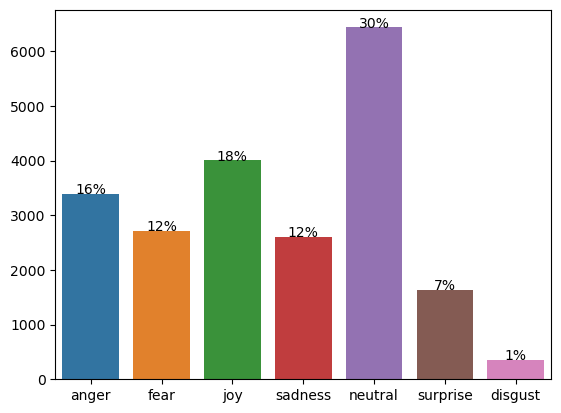

In [93]:
# HERE COMES THE CODE TO CHECK THE DATA AND ANALYSE THE DISTRIBUTION OVER THE EMOTION LABELS

labels = combined_train_labels #assigning a variable to the list of combined labels

# Counting label statistics
label_counts = Counter(labels)
sorted_labels = list(label_counts.keys())
label_counts = list(label_counts.values())

print('The labels are:', sorted_labels)
print('The labels and their respective values are:', label_counts)

# Plotting the label distribution
util.plot_labels_with_counts(sorted_labels, label_counts)


In [94]:
import pandas as pd

# Create a dataframe from the combined instances and labels
df_combined = pd.DataFrame({
    'Text': combined_train_instances,
    'Label': combined_train_labels
})

# Export to a CSV file
df_combined.to_csv('COMBINED_data.csv', index=False)


In [95]:
# HERE COMES THE CODE TO TRAIN AN SVM CLASSIFIER WITH A BOW TFIDF DATA REPRESENTATION

#Step1 
#Representing thecombined text data as BoW vectors 

combined_train_instances = df_combined['Text'].values #using the balanced combined data as the source for the texts
frequency_threshold = 5  # If a token appears fewer times than 5 it will be ignored
text_vec = CountVectorizer(min_df=frequency_threshold,
                             tokenizer=nltk.word_tokenize) #I choose not to remove stopwords because they cary improtant meaning
text_count_vectors = text_vec.fit_transform(combined_train_instances) #convertig raw frequency counts into TF-IDF values
tfidf_transformer = TfidfTransformer()
training_tfidf_vectors = tfidf_transformer.fit_transform(text_count_vectors) #to represent the text according to the vector model of the training data and ignore all out-of-vocabulary words in the test texts


# printing the total number of word features
print("Total number of word features:", len(text_vec.vocabulary_))
print()
print('The dimensions of the training matrix are:', training_tfidf_vectors.shape)
print()
print(f'''The values for the first 50 dimensions with tf-idf values:
{training_tfidf_vectors.toarray()[0][:50]}''')
print()


# printing the vocabulary of all the sentences and their mapped feature names
print('The vocabulary of all the sentences consists of the following words:', 
      list(text_vec.vocabulary_.keys()))
print('These words are mapped to the data columns as feature names:', 
      text_vec.get_feature_names_out())

C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\feature_extraction\text.py:525: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Total number of word features: 3436

The dimensions of the training matrix are: (21157, 3436)

The values for the first 50 dimensions with tf-idf values:
[0.22429367 0.36236274 0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.20959204 0.         0.         0.         0.
 0.05344197 0.         0.13617202 0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.        ]

The vocabulary of all the sentences consists of the following words: ['how', 'the', 'fu', '*', 'k', '!', 'who', 'heck', 'moved', 'my', 'fridge', '...', 'should', 'i', 'knock', 'door', '.', '#', 'angry', 'mad', 'so', 'indian', 'uber', 'driver', 'just', 'called', 'someone', 'n', 'word', 'if', 'was', "n't", 'in', 'a', 'moving', "'d", 'have', 'out', '

In [97]:
#Step2 --> I will train an SVM classifier based on the combined dataset
training_labels = df_combined['Label']
svm_linear_clf = svm.LinearSVC(max_iter=2000)
svm_linear_clf.fit(training_tfidf_vectors, training_labels)

C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


LinearSVC(max_iter=2000)

## 4. Saving the final combined classifier to disk

In [98]:
# saving the countvectorizer
filename_vectorizer = 'text_vectorizer.sav'
pickle.dump(text_vec, open(filename_vectorizer, 'wb'))

# saving the tfidf transformer
filename_tfidftransformer = 'text_tfidf_transformer.sav'
pickle.dump(tfidf_transformer, open(filename_tfidftransformer, 'wb'))

# saving the classifier to disk
filename_classifier = 'svm_linear_clf_bow.sav'
pickle.dump(svm_linear_clf, open(filename_classifier, 'wb'))

# End of notebook